## ARMA Model

Combination of:
- AR (past values)
- MA (past errors)



### Use Case:
Works only for stationary data



### Idea:
Uses both past values and past errors

<img src="ARMA_working.png" alt="Time Series info" width="900" height="600" />

* ### `ARMA model is powerful because it learns from both past values and past errors — giving more realistic predictions`

### The Code Flow

Our pipeline follows a this sequence for Time Series forecasting:

1. **Load Data:** Fetch the US Industrial Production Index (INDPRO).
2. **Check Stationarity:** Use a statistical test to see if the data has a stable mean/variance.
3. **Transform (If Necessary):** Apply differencing if the data is not stationary.
4. **Train-Test Split:** Keep the last 24 months hidden from the model to test its true accuracy.
5. **Rolling Forecast:** Predict one step ahead, add the actual value to the history, and predict the next step (mimicking real-world deployment).
6. **Evaluate:** Calculate the Mean Squared Error (MSE).
7. **Visualize:** Plot the results to visually inspect the model's accuracy.

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")


Dataset Summary: Industrial Production: Total Index (INDPRO)

- This dataset measures the real output (quantity) of the US industrial sector, covering Manufacturing, Mining, and Electric/Gas Utilities.

-  It is an Index (2017 = 100), meaning the values represent production levels relative to the average output of the year 2017.

- As of March 2026, the index value is 101.7898, indicating production is ~1.79% higher than 2017 levels.

- High-frequency monthly data with a deep historical reach starting from January 1919.

-  It is a "Headline Figure" used to identify business cycles. The dataset includes shaded recession periods, showing how production typically drops during economic downturns.

In [11]:
# 1. Load Real-World Manufacturing Dataset
# INDPRO: Industrial Production Index (Measures real manufacturing output)
print("Fetching real-world manufacturing dataset (INDPRO)...")
# url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=INDPRO"

df = pd.read_csv('INDPRO.csv', parse_dates=['observation_date'], index_col='observation_date')
df.rename(columns={'INDPRO': 'Production'}, inplace=True)

# Using data from the year 2000 onwards for a modern timeline
data = df[df.index >= '2000-01-01']['Production']

Fetching real-world manufacturing dataset (INDPRO)...


###  Core Concepts: Stationarity & The ADF Test

* **What is Stationarity?** A time series is "stationary" if its statistical properties (like the average value and the spread/variance of the data) do not change over time. 
  * *Why it matters:* ARMA models cannot handle data with long-term upward/downward trends or repeating seasonal cycles. They need data that fluctuates around a flat, horizontal line (usually zero).
  
* **What is the ADF Test?** The Augmented Dickey-Fuller (ADF) test is a mathematical check for stationarity. 
  * **Rule:** If the `p-value` is less than 0.05, the data is stationary.
  * **Our Case:** Our raw production data had a p-value of 0.23 (not stationary due to economic growth over time). We applied **first-order differencing** (calculating the month-to-month change instead of total volume). After differencing, the new p-value dropped to 0.00, meaning it was perfectly stationary and ready for the ARMA model.

In [12]:
# 2. Check Stationarity (ADF Test)
print("\n--- Checking Stationarity ---")
result = adfuller(data)
print(f"ADF Statistic (Original): {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

# If p-value > 0.05, data is not stationary. We must take the first difference.
if result[1] > 0.05:
    print("Result: Data is NOT stationary. Applying first-order differencing...")
    # Taking the difference between consecutive months to remove trend
    data = data.diff().dropna()
    
    # Verify again with ADF Test
    result_diff = adfuller(data)
    print(f"New p-value after differencing: {result_diff[1]:.4f}")
    print("Result: Data is now stationary. We can apply ARMA!\n")
else:
    print("Result: Data is already stationary.\n")


--- Checking Stationarity ---
ADF Statistic (Original): -2.1254
p-value: 0.2344
Result: Data is NOT stationary. Applying first-order differencing...
New p-value after differencing: 0.0000
Result: Data is now stationary. We can apply ARMA!



In [13]:
# 3. Train-Test Split 
# We will use the last 24 months for our testing phase
train_data = data.iloc[:-24]
test_data = data.iloc[-24:]

print(f"Training Data length: {len(train_data)}")
print(f"Testing Data length: {len(test_data)}\n")

Training Data length: 290
Testing Data length: 24



###  Model Parameters: `p, d, q = 2, 0, 2`

We used `ARIMA(order=(2, 0, 2))` to build our model.

* **`p = 2` (AutoRegressive):** The model looks at the actual production changes from the last **2 months** to predict the next month.
* **`d = 0` (Differencing):** Since we already differenced the data manually during the stationarity check, we tell the model to apply 0 additional differencing. This effectively turns the ARIMA function into a pure ARMA model.
* **`q = 2` (Moving Average):** The model looks at the prediction errors (the mistakes it made) from the last **2 months** to adjust its next forecast.

In [21]:
# 4. Fit ARMA Model & Rolling Forecast
print("--- Starting Robust Rolling Forecast ---")
history = [x for x in train_data]
predictions = []

# ARMA order: p=2 (AR), d=0 (No further differencing needed), q=2 (MA)
p, d, q = 2, 0, 2 

for t in range(len(test_data)):
    try:
        # Fallback constraint to avoid mathematical failure
        if np.var(history) == 0:
            yhat = history[-1]
        else:
            # ARIMA with d=0 functions exactly as an ARMA model
            model = ARIMA(history, 
                          order=(p, d, q), 
                          enforce_stationarity=False, 
                          enforce_invertibility=False)
            
            fitted_model = model.fit(method='innovations_mle')
            yhat = fitted_model.forecast()[0]
            
    except Exception as e:
        print(f"Warning: Error at step {t}. Using naive forecast.")
        yhat = history[-1]

    predictions.append(yhat)
    obs = test_data.iloc[t]
    history.append(obs)
    
    # Print progress every 4 steps
    if t % 4 == 0:
        print(f"Step {t}: Predicted = {yhat:.2f}, Actual = {obs:.2f}")
    

--- Starting Robust Rolling Forecast ---
Step 0: Predicted = -0.14, Actual = -0.21
Step 4: Predicted = -0.20, Actual = 0.46
Step 8: Predicted = 0.04, Actual = 1.03
Step 12: Predicted = -0.16, Actual = 0.09
Step 16: Predicted = 0.04, Actual = -0.27
Step 20: Predicted = 0.07, Actual = 0.53


###  Evaluating


* **Mean Squared Error (MSE)** measures the average squared difference between the estimated values and the actual value. A lower number is better.
* Because we differenced our data, we are predicting the *change* in production (small numbers like 0.5, -0.2, 1.0) rather than the total volume (large numbers like 100, 105). Missing a prediction by a fraction of a point results in a very low MSE, proving our model tracked the actual changes very closely.

In [ ]:
# 5. Evaluation
mse = mean_squared_error(test_data, predictions)
print(f"\nMean Squared Error (MSE): {mse:.2f}")



Mean Squared Error (MSE): 0.33


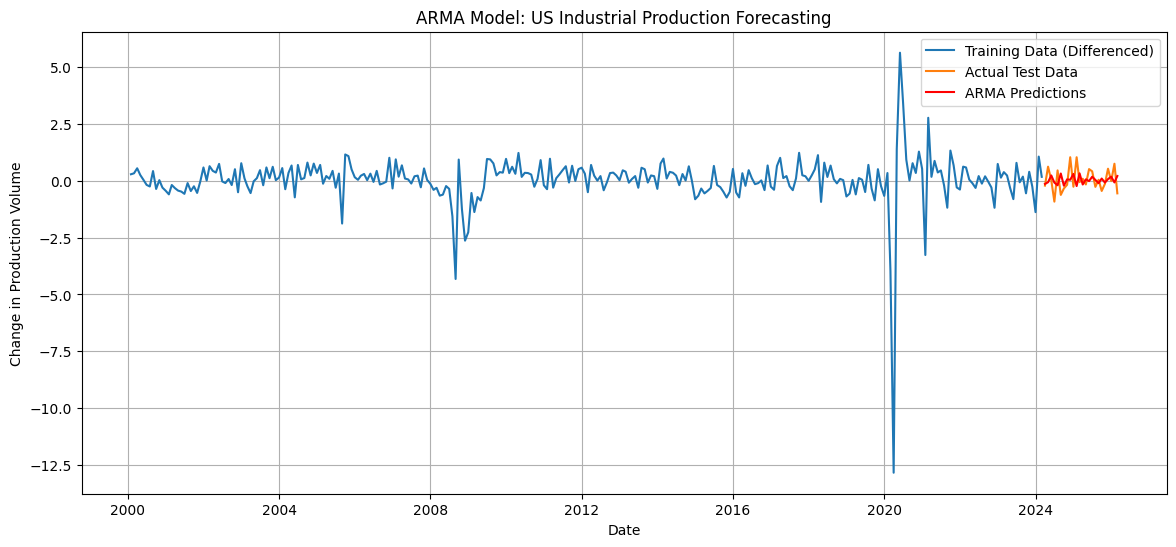

In [ ]:
# 6. Visualization using Matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot Training Data
plt.plot(train_data.index, train_data, 
         label='Training Data (Differenced)')

# Plot Actual Test Data
plt.plot(test_data.index, test_data, 
         label='Actual Test Data')

# Plot Predictions
plt.plot(test_data.index, predictions, 
         label='ARMA Predictions', 
         color='red')

# Labels and Title
plt.title('ARMA Model: US Industrial Production Forecasting')
plt.xlabel('Date')
plt.ylabel('Change in Production Volume')

# Legend and Grid
plt.legend()
plt.grid(True)

# Show Plot
plt.show()


###  How to Read the Output Graph

* **Y-Axis (Change in Production Volume):** Because we transformed the data to be stationary, the Y-axis no longer shows total units produced. It shows how much production *grew or shrank* compared to the previous month.
* **The Flat Blue Line (Training Data):** The line mostly jumps up and down around the 0 mark. This is the visual proof that our data is stationary.
* **The Massive Spike in 2020:** You will notice a giant drop below -10, followed immediately by a spike up to 5. This is the COVID-19 lockdown and subsequent reopening. 
* **The Red Line (Predictions):** On the far right, the red line (ARMA predictions) closely overlaps the actual test data line. When the actual data dipped slightly, our red line dipped slightly. This confirms the model successfully learned the recent patterns.

##  The Standard Pipeline to Train ANY ARMA Model


If you need to build an ARMA model for a new dataset, follow this exact checklist:

1. **Ingest & Clean:** Load the time series and handle any missing values.
2. **Test Stationarity:** Run the ADF Test.
3. **Make Stationary:** If ADF p-value > 0.05, apply `df.diff().dropna()`.
4. **Identify p and q:** Plot the ACF (Autocorrelation) and PACF (Partial Autocorrelation) graphs to find the mathematically optimal numbers for `p` and `q`. *(In this notebook, we hardcoded 2,0,2 as a starting baseline).*
5. **Fit the Model:** Train the `ARIMA(p, 0, q)` model on the training set.
6. **Forecast:** Use a rolling forecast to predict the test set.
7. **Evaluate:** Check MSE and plot the actuals vs. predictions.

<div style="text-align: center; font-size: 16px;">
<b>Created by</b><br>
Priyanka Deore & Kunal Mahadule
</div>